In [2]:
# Ignore
from IPython.display import Image

## Q1. Write pseudocode for a parallel version of merge sort using a serial merge step. Compute the span and parallelism of your code. How useful is this code?

You may assume that the work is unchanged, $O(n\log n)$

Something like this will do:

```
def mergesort(X)
    n = len(X)
    if n<=1 return X
    m = int(n/2)
    spawn L = mergesort(X[1 to m])
    R = mergesort(X[m+1 to n])
    sync
    X = merge(L, R)
    return X
```

We're assuming $T_1(n)=O(n\log n)$.

We compute span $T_\infty(n)=T_\infty(n/2)+\Theta(n)$ because the two mergesort recursions run in parallel. Apply master method with $a=1$, $b=2$, $d=1$ to get $\log_b a=\log_2 1=0<d=1$ so $T_\infty(n)=\Theta(n)$.

So parallelism is $T_1/T_\infty=O(\log n)$. This isn't great because for a fixed number of processors $P$, if you wanted to get a linear speed up you would need $n=\Omega(e^P)$.

## Q2. Write pseudocode for a parallel merge step, using the hints below. Compute its span.

If you're merging L and R, find the midpoint value x of L, and divide L and R into halves which are less than or greater than x. Use an efficient (serial) algorithm to find the midpoint of R. Find an upper bound of the span of the two spawned merge steps.

 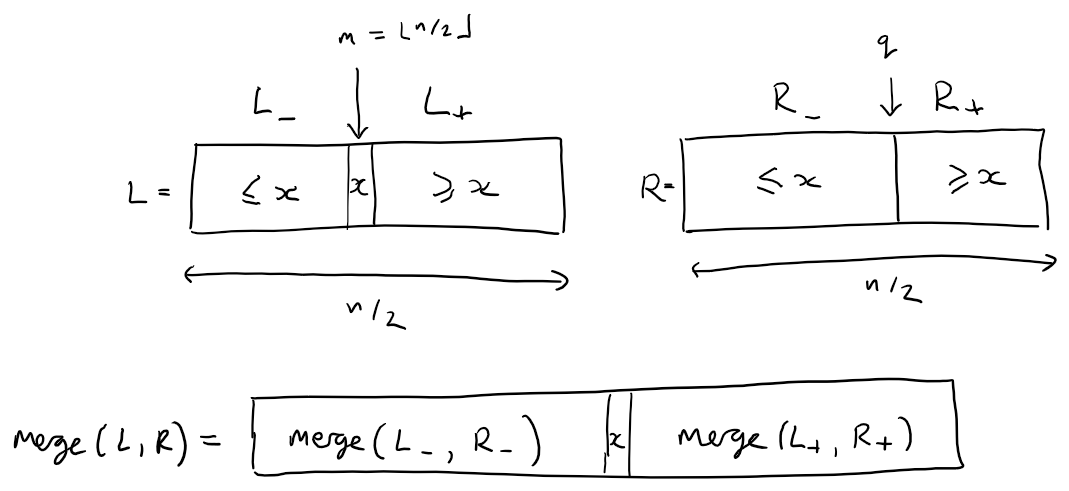



<div class="alert alert-block alert-info">
You may want to use the following variant of the master method:

If $T(n)=aT(n/b)+f(n)$ and $f(n)=\Theta(n^{\log_b a}(\log n)^k)$ then $T(n)=\Theta(n^{\log_b a}(\log n)^{k+1})$.
</div>

Let's expand that diagram above a bit.

<img src=" 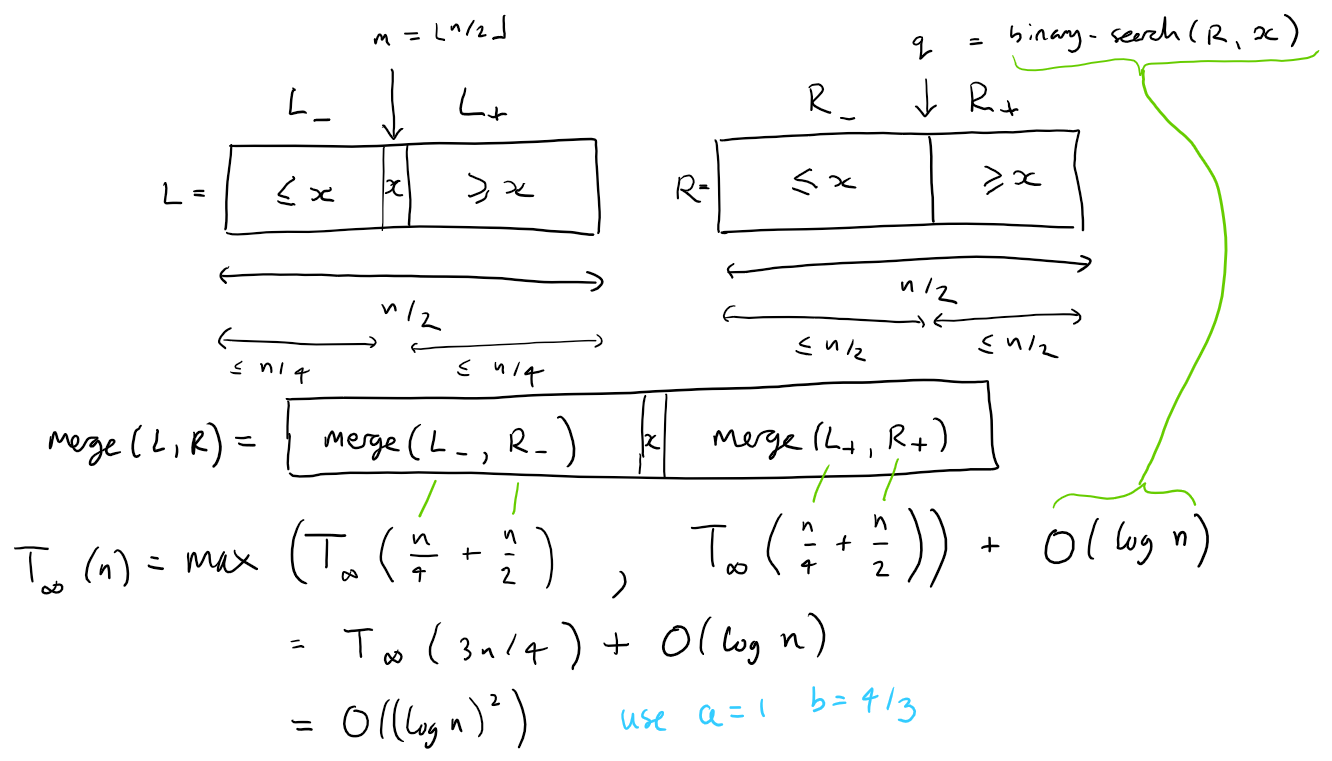"/>

We use binary search to find $q$, which is $O(\log n)$.

Pseudocode:

```
def parallel_merge(L, R, out)
    if len(L)<len(R) swap L and R
    if len(L)==0 return
    m = int( len(L)/2 )
    q = binary_search(R, L[m])
    r = m+q
    out[r] = L[m]
    spawn parallel_merge(L[1 to m-1], R[1 to q], out[1 to r-1])
    parallel_merge(L[m+1 to len(L)], R[q+1 to len(R)], out[r+1 to len(out)])
    sync
```

The reason to do this weird thing comes out in the analysis of the span.

The span of the ``merge(L, R)`` in the diagram will be the max of the spans of the two recursive calls plus the time it takes to do the binary search (which is $O(\log n)$). The recursive calls are each with half of $L$, which therefore has size $n/4$, and at most all of $R$, so size at most $n/2$. So the total size is therefore $3n/4$. They run in parallel, so you just have one of them to get the recurrence in the diagram. We can solve this using the variant of the master method to get $T_\infty(n)=O((\log n)^2)$.

## Q3. Write pseudocode for a fully parallel merge sort, and compute its span and parallelism. How useful is this code?

You may again assume the work is $O(n\log n)$.

Just make the merge parallel:

```
def mergesort(X)
    n = len(X)
    if n<=1 return X
    m = int(n/2)
    spawn L = mergesort(X[1 to m])
    R = mergesort(X[m+1 to n])
    sync
    X = parallel_merge(L, R)
    return X
```

Now, to compute the span we get $T_\infty(n)=T_\infty(n/2)+\Theta((\log n)^2)$. Applying the variant of the master method again we get $T_\infty(n)=\Theta((\log n)^3)$. This gives us parallelism $T_1/T_\infty=O(n/(\log n)^2)$ which is much better!

## Q4 (optional). Write code to implement this and verify that it works.

You don't need to actually use multiple processors, just verify that the code works.

In [1]:
# This code doesn't make use of multiple processors

from bisect import bisect_left # for binary search

def parallel_merge(L, R):
    if len(L)<len(R):
        L, R = R, L
    if len(L)==0:
        return L
    m = len(L)//2
    q = bisect_left(R, L[m])
    return parallel_merge(L[:m], R[:q])+[L[m]]+parallel_merge(L[m+1:], R[q:])

def mergesort(X):
    if len(X)<=1:
        return X
    m = len(X)//2
    L = mergesort(X[:m])
    R = mergesort(X[m:])
    return parallel_merge(L, R)

import random

# generate 10 random lists of length 100 and sort them
for _ in range(10):
    X = [random.random() for _ in range(100)]
    Y = mergesort(X)
    Z = sorted(X)
    assert all(y==z for y, z in zip(Y, Z))